# 04 — Shapley, Aumann–Shapley, functional ANOVA, and SHAP

**Graduate course: Decomposition Analysis in Python**

## Learning objectives

- Derive exact Shapley values from random-order marginal contributions.
- Prove efficiency and interpret the Shapley axioms.
- Derive Aumann–Shapley as a line-integral allocation.
- Construct functional ANOVA and variance components.
- Derive SHAP for model predictions and separate predictive from causal attribution.

## Roadmap and notation

### Guiding question

When several factors interact, what principled rule can allocate a total change or model prediction among them?

### Prerequisites

Sets, averages, conditional expectations, partial derivatives, and basic variance. The line-integral and orthogonality arguments are derived explicitly, so prior game theory is not required.

### Symbols

- $N=\{1,\ldots,p\}$: all players or features.
- $S\subseteq N$: coalition already present.
- $v(S)$: value produced by coalition $S$.
- $v(S\cup\{j\})-v(S)$: marginal contribution of player $j$ after $S$.
- $\phi_j$: Shapley allocation to player $j$.

The sequence is deliberate: discrete allocation (Shapley), continuous allocation (Aumann–Shapley), global function/variance decomposition (functional ANOVA), and prediction explanation (SHAP). Their shared vocabulary should not obscure that they decompose different mathematical objects.

## Cooperative-game allocation

For value function $v(S)$ and $p$ players,
$$\phi_j=\sum_{S\subseteq N\setminus\{j\}}\frac{|S|!(p-|S|-1)!}{p!}[v(S\cup\{j\})-v(S)].$$
The allocation is efficient, symmetric, additive, and assigns zero to null players. Aumann–Shapley is a continuous-path analogue. Functional ANOVA decomposes a square-integrable function into main and interaction functions relative to an input distribution.

SHAP applies Shapley values to model predictions. The coalition value depends on a background distribution and on whether “missing” features are integrated conditionally or interventionally. Therefore a SHAP value is a model-and-background-specific predictive attribution, not automatically a causal effect.

## 1. Shapley value: derivation, axioms, and proof of efficiency

### The allocation problem

Let $N=\{1,\ldots,p\}$ be a set of players and let $v:2^N\rightarrow\mathbb R$ be a value function. Usually $v(\varnothing)=0$; if it is not, allocate the surplus $v(N)-v(\varnothing)$. For player $j$, the marginal contribution after coalition $S$ is

$$\Delta_j(S)=v(S\cup\{j\})-v(S),\qquad j\notin S.$$

Shapley's idea is to imagine that players enter in a random order. If $S$ is the set appearing before $j$, then $j$ receives $\Delta_j(S)$. Averaging over all $p!$ orders gives

$$\phi_j(v)=\frac{1}{p!}\sum_{\pi}
\left[v(P_j^\pi\cup\{j\})-v(P_j^\pi)\right],$$

where $P_j^\pi$ is the predecessor set of $j$ in permutation $\pi$.

The same predecessor set $S$ occurs in $|S|!(p-|S|-1)!$ permutations: members of $S$ can be ordered before $j$ in $|S|!$ ways and the remaining players after $j$ in $(p-|S|-1)!$ ways. Grouping permutations by predecessor set yields the familiar coalition formula

$$\boxed{\phi_j(v)=\sum_{S\subseteq N\setminus\{j\}}
\frac{|S|!(p-|S|-1)!}{p!}\,[v(S\cup\{j\})-v(S)]}.$$

### Why the allocations sum to the total

For any fixed order $\pi=(\pi_1,\ldots,\pi_p)$, successive marginal contributions telescope:

$$\sum_{k=1}^p\left[v(\{\pi_1,\ldots,\pi_k\})
-v(\{\pi_1,\ldots,\pi_{k-1}\})\right]=v(N)-v(\varnothing).$$

Averaging an equality over all permutations preserves it, so

$$\boxed{\sum_{j=1}^p\phi_j(v)=v(N)-v(\varnothing)}.$$

This is **efficiency**, not causality.

### Characterizing axioms

Shapley (1953) showed that the allocation is uniquely characterized by:

1. **Efficiency:** all surplus is allocated.
2. **Symmetry:** players with identical marginal contributions receive the same value.
3. **Dummy/null player:** if $j$ never changes $v(S)$, then $\phi_j=0$.
4. **Additivity:** for games $v$ and $u$, $\phi(v+u)=\phi(v)+\phi(u)$.

A proof sketch uses unanimity games $u_T(S)=\mathbf 1\{T\subseteq S\}$ as a basis for all set functions. Symmetry, efficiency, and the dummy axiom force each member of $T$ to receive $1/|T|$ in $u_T$; additivity then determines the value uniquely for any linear combination of unanimity games.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from itertools import permutations, combinations
pd.options.display.float_format = '{:,.4f}'.format
plt.style.use('seaborn-v0_8-whitegrid')
rng = np.random.default_rng(42)

In [2]:
features=['traffic','conversion','price']
base={'traffic':1000.,'conversion':.04,'price':50.}; current={'traffic':1200.,'conversion':.05,'price':48.}
def revenue(z): return z['traffic']*z['conversion']*z['price']
def value(S):
    z={k:(current[k] if k in S else base[k]) for k in features}; return revenue(z)-revenue(base)
phi={j:0. for j in features}
for order in permutations(features):
    S=set()
    for j in order:
        phi[j]+=(value(S|{j})-value(S))/__import__("math").factorial(len(features)); S.add(j)
pd.Series({**phi,'allocated':sum(phi.values()),'observed':revenue(current)-revenue(base)})

traffic      440.6667
conversion   538.6667
price        -99.3333
allocated    880.0000
observed     880.0000
dtype: float64

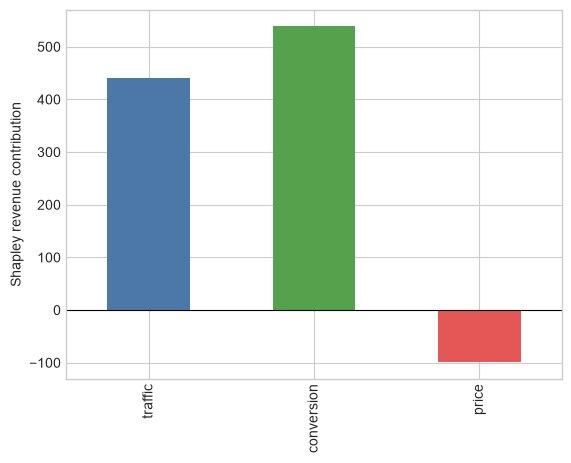

In [3]:
pd.Series(phi).plot.bar(color=['#4C78A8','#54A24B','#E45756']); plt.axhline(0,color='black',lw=.8); plt.ylabel('Shapley revenue contribution'); plt.show()

## Reading the worked example

Revenue increases by 880. Shapley allocates +440.67 to traffic, +538.67 to conversion, and −99.33 to price. `allocated = observed` verifies efficiency. The negative price contribution reflects the fall from 50 to 48; it does not estimate price elasticity.

Why is this preferable to one arbitrary replacement order? Every possible order is averaged, so interaction credit is shared symmetrically. The later baseline-sensitivity table shows that symmetry does not make the answer baseline-free.

## Shapley application: interacting growth drivers

For

$$\text{Revenue}=\text{Traffic}\times\text{CVR}\times\text{Price},$$

the factors interact: the value of an extra conversion-rate point depends on traffic and price. A one-order replacement gives the interaction to whichever factor arrives later. Shapley averages every order, creating a symmetric exact allocation.

The business value function must still be declared. Here,

$$v(S)=R(x_S^1,x_{-S}^0)-R(x^0),$$

where drivers in $S$ use current values and the rest use baseline values. This is a descriptive hybrid game. It does not represent $E[R\mid do(X_S=x_S^1)]$.

In [4]:
# Baseline sensitivity of the revenue Shapley allocation
def shapley_between(baseline, target):
    def v(S):
        z={k:(target[k] if k in S else baseline[k]) for k in features}
        return revenue(z)-revenue(baseline)
    out={j:0. for j in features}
    orders=list(permutations(features))
    for order in orders:
        S=set()
        for j in order:
            out[j]+=(v(S|{j})-v(S))/len(orders); S.add(j)
    return out
alt={'traffic':900.,'conversion':.045,'price':52.}
pd.DataFrame({'original baseline':shapley_between(base,current),
              'alternative baseline':shapley_between(alt,current)})

,original baseline,alternative baseline
traffic,440.6667,712.0000
conversion,538.6667,262.0000
price,-99.3333,-200.0000


### Interpreting the baseline-sensitivity result

Both columns satisfy efficiency relative to their own baseline, yet the driver allocations differ materially. Shapley removes arbitrary **order** dependence after a game is defined; it does not remove dependence on the baseline, value function, unit of analysis, or data-generating model.

For growth reporting, disclose the baseline (previous month, budget, forecast, control group, or long-run mean) and show sensitivity to plausible alternatives.

## 2. Aumann–Shapley: continuous-path attribution

Shapley treats players as discrete entrants. Aumann–Shapley extends the allocation idea to continuously divisible factors. Let $F:\mathbb R^p\rightarrow\mathbb R$ be differentiable, with baseline $x^0$ and target $x^1$. Along the straight-line path

$$x(t)=x^0+t(x^1-x^0),\qquad 0\le t\le1,$$

the Aumann–Shapley contribution of coordinate $j$ is

$$\boxed{AS_j=(x_j^1-x_j^0)\int_0^1
\frac{\partial F(x(t))}{\partial x_j}\,dt}.$$

The chain rule proves efficiency:

$$\frac{dF(x(t))}{dt}=
\sum_j\frac{\partial F(x(t))}{\partial x_j}(x_j^1-x_j^0).$$

Integrating from 0 to 1 gives

$$F(x^1)-F(x^0)=\sum_j AS_j.$$

Unlike the discrete Shapley value, Aumann–Shapley depends on a continuous path. The straight line is conventional; a different path can produce a different allocation when interactions are present.

For a two-factor product $F(x_1,x_2)=x_1x_2$, integration gives

$$AS_1=\Delta x_1\left(x_2^0+\frac{\Delta x_2}{2}\right),\qquad
AS_2=\Delta x_2\left(x_1^0+\frac{\Delta x_1}{2}\right),$$

which is exactly the equal-interaction split seen in Kitagawa for one product term.

In [5]:
# Numerical Aumann–Shapley allocation along a straight line.
def revenue_vector(x):
    return x[0] * x[1] * x[2]

def revenue_gradient(x):
    traffic, cvr, price = x
    return np.array([cvr*price, traffic*price, traffic*cvr])

x0 = np.array([base['traffic'], base['conversion'], base['price']])
x1 = np.array([current['traffic'], current['conversion'], current['price']])
grid = np.linspace(0, 1, 20_001)
path_points = x0[None, :] + grid[:, None] * (x1-x0)[None, :]
gradients = np.array([revenue_gradient(point) for point in path_points])
average_gradient = np.trapezoid(gradients, grid, axis=0)
as_contributions = (x1-x0) * average_gradient

pd.Series({
    'traffic': as_contributions[0],
    'conversion': as_contributions[1],
    'price': as_contributions[2],
    'allocated': as_contributions.sum(),
    'observed': revenue_vector(x1)-revenue_vector(x0),
})

traffic      440.6667
conversion   538.6667
price        -99.3333
allocated    880.0000
observed     880.0000
dtype: float64

### Aumann–Shapley applications and limitations

Applications include allocating continuously varying costs, emissions, revenue, and risk. In growth analytics it is useful when drivers such as traffic, CVR, and AOV are naturally continuous and gradients are available.

- It requires a differentiable function or a numerical gradient.
- The path may pass through unrealistic business states.
- Results change with path choice unless the differential allocation is path-independent in the relevant sense.
- It attributes a finite change; it does not estimate a behavioral derivative or causal elasticity merely because derivatives appear in the formula.
- Numerical integration adds approximation error, which should be checked by refining the grid.

The displayed `allocated` and `observed` values coincide up to numerical error, verifying the line-integral identity.

## 3. Functional ANOVA: decomposing a function and its variance

Functional ANOVA answers a different question. Instead of allocating one finite change, it decomposes a square-integrable function $f(X)$ into main effects and interactions relative to an input distribution.

For independent inputs $X=(X_1,\ldots,X_p)$,

$$f(X)=f_\varnothing+\sum_j f_j(X_j)
+\sum_{j<k}f_{jk}(X_j,X_k)+\cdots+f_{1\cdots p}(X).$$

The components are defined recursively:

$$f_\varnothing=E[f(X)],$$

$$f_j(x_j)=E[f(X)\mid X_j=x_j]-f_\varnothing,$$

$$f_{jk}(x_j,x_k)=E[f(X)\mid X_j=x_j,X_k=x_k]
-f_j(x_j)-f_k(x_k)-f_\varnothing,$$

and analogously for higher orders by subtracting all lower-order terms.

Under the product measure induced by independent inputs, each nonempty component integrates to zero over any of its arguments. Consequently distinct components are orthogonal:

$$E[f_S(X_S)f_T(X_T)]=0\quad(S\ne T).$$

Orthogonality yields the variance decomposition

$$\boxed{\operatorname{Var}(f(X))=
\sum_{\varnothing\ne S\subseteq N}V_S},\qquad
V_S=\operatorname{Var}(f_S(X_S)).$$

Sobol indices normalize these components:

$$S_j=\frac{V_j}{\operatorname{Var}(f(X))},\qquad
S_j^{\text{total}}=
\frac{\sum_{S\ni j}V_S}{\operatorname{Var}(f(X))}.$$

Functional ANOVA is therefore global and distribution-dependent. It is not the same object as a local Shapley explanation.

In [6]:
# Exact functional ANOVA for f(x1,x2)=x1+x2+2*x1*x2,
# with independent, centered Uniform(-1,1) inputs.
n_anova = 300_000
x_anova = rng.uniform(-1, 1, size=(n_anova, 2))
x_1, x_2 = x_anova[:, 0], x_anova[:, 1]

f_empty = 0.0
f_1 = x_1
f_2 = x_2
f_12 = 2*x_1*x_2
f_total = f_empty + f_1 + f_2 + f_12

variance_components = pd.Series({
    'V1 main effect': np.var(f_1),
    'V2 main effect': np.var(f_2),
    'V12 interaction': np.var(f_12),
})
anova_summary = pd.DataFrame({
    'variance': variance_components,
    'share': variance_components / np.var(f_total),
})
anova_summary.loc['sum of components'] = anova_summary.sum()
anova_summary.loc['observed Var(f)'] = [np.var(f_total), 1.0]
anova_summary

,variance,share
V1 main effect,0.3332,0.3006
V2 main effect,0.3329,0.3003
V12 interaction,0.4439,0.4006
sum of components,1.1100,1.0015
observed Var(f),1.1083,1.0000


### Reading and applying functional ANOVA

For independent centered inputs, the main effects $x_1$ and $x_2$ and interaction $2x_1x_2$ are orthogonal. The Monte Carlo sum of component variances is therefore close to the observed variance of $f$; the small discrepancy is simulation error.

Growth applications include determining whether variation in predicted conversion is dominated by acquisition channel, user intent, pricing, or interactions; screening simulator inputs; and diagnosing whether a KPI model is mostly additive.

Limitations:

- Classical uniqueness and orthogonality rely on a chosen product measure and usually independent inputs.
- With dependent features, several generalized decompositions exist and answer different questions.
- A large variance share means the feature explains model-output variability under the chosen distribution, not that intervening on it produces a large effect.
- Estimates require integration or Monte Carlo sampling; rare but important regions can be missed.
- Results change when the reference population or input distribution changes.

## 4. SHAP: Shapley values for model predictions

SHAP does not introduce a new cooperative-game solution; it specifies games for explaining a fitted prediction $f(x)$. An additive explanation has the form

$$g(z')=\phi_0+\sum_{j=1}^p\phi_jz'_j,$$

where $z'_j=1$ means feature $j$ is present. **Local accuracy** requires

$$f(x)=\phi_0+\sum_j\phi_j.$$

Usually $\phi_0=E[f(X)]$, so the feature values allocate

$$f(x)-E[f(X)].$$

The crucial scientific choice is the coalition value. Two common definitions are

$$v_{\text{cond}}(S)=E[f(X)\mid X_S=x_S]$$

and

$$v_{\text{marg}}(S)=E_{X_{-S}}[f(x_S,X_{-S})].$$

The conditional game respects observed dependence but can give attribution to a feature unused by the model because it carries information about another feature. The marginal game evaluates the model after breaking dependence and may create implausible feature combinations.

A causal game is different:

$$v_{\text{causal}}(S)=E[Y\mid do(X_S=x_S)].$$

It requires a structural causal model or identified intervention distribution. Calling marginal SHAP “interventional” in software does not by itself make it causal.

### Linear-model special case

If $f(x)=\beta_0+\sum_j\beta_jx_j$ and the marginal game uses background means $\mu_j=E[X_j]$, then

$$\boxed{\phi_j=\beta_j(x_j-\mu_j)},\qquad
\phi_0=\beta_0+\sum_j\beta_j\mu_j.$$

This follows because the marginal contribution of feature $j$ is the same for every coalition, so averaging does not change it.

In [7]:
# Verify local accuracy for marginal SHAP in a linear conversion model.
feature_names = ['intent_score', 'sessions', 'discount']
beta = np.array([0.30, 0.08, 0.45])
intercept = -1.20
background_mean = np.array([0.0, 3.0, 0.10])
customer = np.array([1.2, 5.0, 0.25])

baseline_prediction = intercept + background_mean @ beta
customer_prediction = intercept + customer @ beta
linear_shap = beta * (customer-background_mean)

pd.Series({
    'base value E[f(X)]': baseline_prediction,
    **dict(zip(feature_names, linear_shap)),
    'base + SHAP': baseline_prediction + linear_shap.sum(),
    'model prediction f(x)': customer_prediction,
})

base value E[f(X)]      -0.9150
intent_score             0.3600
sessions                 0.1600
discount                 0.0675
base + SHAP             -0.3275
model prediction f(x)   -0.3275
dtype: float64

## Growth-marketing uses of SHAP—and defensible language

Appropriate uses include:

- explaining why a churn or conversion model scored a user above its background expectation;
- detecting leakage, such as `discount_seen` measured after treatment;
- comparing model behavior across cohorts or acquisition channels;
- identifying nonlinearities and interactions that deserve model or product investigation;
- monitoring explanation drift when the background population changes.

Defensible statement:

> Relative to the declared background dataset, the fitted model assigns +0.067 probability points to recent sessions for this user.

Unsupported statement without causal identification:

> Increasing sessions will cause conversion to rise by 0.067.

Additional traps include correlated channel and geography features, aggregation of $|\phi_j|$ that hides direction, poorly calibrated predictions, and post-treatment features that are predictive but not valid intervention levers.

## Comparison of the four methods

| Method | Object decomposed | Output | Exactness | Main reference choice | Causal by itself? |
|---|---|---|---|---|---|
| Shapley | discrete coalition value $v(S)$ | allocation of $v(N)-v(\varnothing)$ | exact | value function/baseline | no |
| Aumann–Shapley | differentiable finite change $F(x^1)-F(x^0)$ | path-integrated contributions | exact up to numerical integration | baseline, target, path | no |
| Functional ANOVA | function $f(X)$ under a distribution | main/interaction functions and variance shares | exact in population | input distribution/dependence structure | no |
| SHAP | fitted prediction relative to background | local feature attributions | locally exact for chosen game | model, background, missing-feature semantics | no |

The common theme is allocation. The mathematical objects, reference choices, and permissible interpretations are different.

## Limitations and robustness

- **Shapley:** exponential exact computation, value-function dependence, and no canonical baseline.
- **Aumann–Shapley:** differentiability and path dependence; numerical integration error.
- **Functional ANOVA:** distribution dependence and complications under correlated inputs.
- **SHAP:** model, background, and missing-feature dependence; predictive explanation can be mistaken for intervention effect.
- For approximate allocations, report Monte Carlo or numerical error in addition to sampling uncertainty.
- Repeat results across plausible baselines/background samples, group strongly collinear variables, and examine stability across model folds and seeds.
- Validate model discrimination and calibration before explaining predictions.
- Never infer causal leverage from attribution magnitude alone.

## What came next

**Aumann & Shapley (1974)** extended discrete cooperative-game allocation to nonatomic/continuous settings. **Hoeffding (1948)** supplied an early orthogonal decomposition underlying functional ANOVA; **Sobol' (1993)** developed variance-based global sensitivity indices. **Lundberg & Lee (2017)** connected additive feature attribution to Shapley values, and **Lundberg et al. (2020)** developed efficient TreeSHAP explanations. **Aas, Jullum & Løland (2021)** addressed dependent features. **Sundararajan & Najmi (2020)** clarified that different coalition games produce different Shapley explanations, while **Heskes et al. (2020)** incorporated explicit causal structure.

## Takeaways and bridge to Notebook 05

1. Shapley uniquely allocates a discrete coalition surplus under its four axioms once $v(S)$ is fixed.
2. Aumann–Shapley allocates a continuous finite change by integrating gradients along a declared path.
3. Functional ANOVA decomposes a function and, under orthogonality, its variance relative to an input distribution.
4. SHAP applies a Shapley game to fitted predictions under declared background and missing-feature semantics.
5. Efficiency does not remove baseline, path, distribution, or model dependence.
6. None of the four methods identifies an intervention effect without additional causal structure.

Notebook 05 completes the course by defining the additional assumptions and research designs needed for causal claims.

### Exercises

1. Change the revenue baseline and recompute discrete Shapley values. Which axioms remain true, and which business interpretation changes?
2. Replace the straight Aumann–Shapley path with a path that changes traffic first and price last. Compare contributions and verify efficiency.
3. Modify the functional ANOVA example so $X_2$ is correlated with $X_1$. Show numerically why the classical variance components no longer add cleanly.
4. Change the SHAP background mean for the linear model. Verify local accuracy and explain why the feature attributions move.
5. For one growth intervention, define separately a descriptive Shapley game, a predictive SHAP game, and a causal estimand.

## Interpretation checklist

1. State the mathematical identity or estimand.
2. Verify exactness numerically.
3. Separate description, prediction, and causation.
4. Report reference population/path/order.
5. Quantify sampling uncertainty when inputs are estimated.

## References

- Shapley, L. S. (1953). A value for n-person games. In *Contributions to the Theory of Games II*. Princeton University Press.
- Aumann, R. J., & Shapley, L. S. (1974). *Values of Non-Atomic Games*. Princeton University Press.
- Hoeffding, W. (1948). A class of statistics with asymptotically normal distribution. *Annals of Mathematical Statistics*, 19, 293–325.
- Lundberg, S. M., & Lee, S.-I. (2017). A unified approach to interpreting model predictions. *NeurIPS 30*, 4765–4774. https://papers.nips.cc/paper/7062
- Sobol', I. M. (1993). Sensitivity estimates for nonlinear mathematical models. *Mathematical Modelling and Computational Experiments*, 1, 407–414.
- Owen, A. B. (2014). Sobol' indices and Shapley value. *SIAM/ASA Journal on Uncertainty Quantification*, 2, 245–251. https://doi.org/10.1137/130936233
- Lundberg, S. M. et al. (2020). From local explanations to global understanding with explainable AI for trees. *Nature Machine Intelligence*, 2, 56–67. https://doi.org/10.1038/s42256-019-0138-9
- Sundararajan, M., & Najmi, A. (2020). The many Shapley values for model explanation. *ICML 2020*, PMLR 119, 9269–9278. https://proceedings.mlr.press/v119/sundararajan20b.html
- Aas, K., Jullum, M., & Løland, A. (2021). Explaining individual predictions when features are dependent. *Artificial Intelligence*, 298, 103502. https://doi.org/10.1016/j.artint.2021.103502
- Heskes, T., Sijben, E., Bucur, I. G., & Claassen, T. (2020). Causal Shapley values: Exploiting causal knowledge to explain individual predictions of complex models. *NeurIPS 33*, 4778–4789.